In [19]:
import pandas as pd
import json as js
import csv
import matplotlib.pyplot as plt
import numpy as np
import math as m
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "Times New Roman",
})

In [20]:
df = pd.read_csv('evaluation_results.csv')
df2 = pd.read_csv('evaluation_no_ctx_results.csv')
df.head()

,Hot Path Predicted,Error Rate,Error Avg,Error Std
0,True,0.041667,0.041667,0.199826
1,True,0.083333,0.083333,0.276385
2,True,0.041667,0.041667,0.199826
3,True,0.000000,0.000000,0.000000
4,True,0.125000,0.125000,0.330719


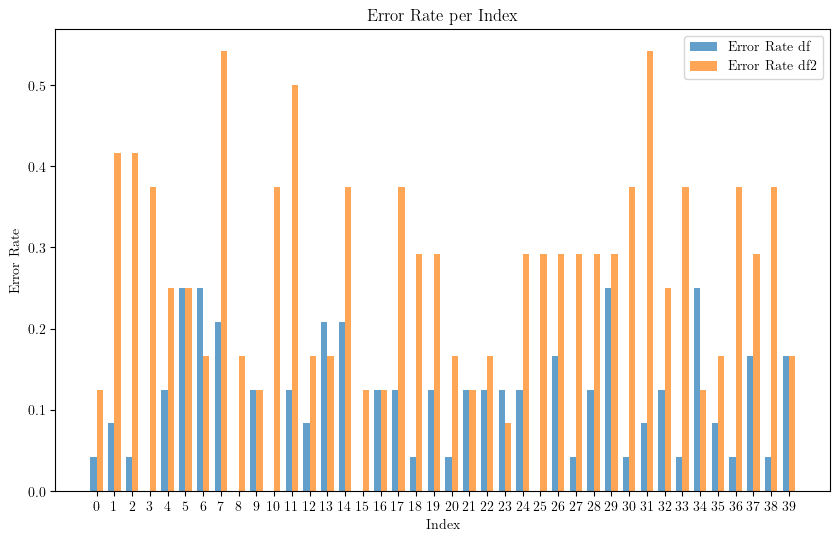

In [21]:
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(df))

plt.bar(index, df["Error Rate"], bar_width, alpha=0.7, label="Error Rate df")
plt.bar(index + bar_width, df2["Error Rate"], bar_width, alpha=0.7, label="Error Rate df2")
plt.xticks(index + bar_width / 2, df.index)
# plt.bar(df.index, df["Error Rate"], color="blue", alpha=0.7, label="Error Rate")
plt.xlabel("Index")
plt.ylabel("Error Rate")
plt.title("Error Rate per Index")
plt.legend()
plt.show()

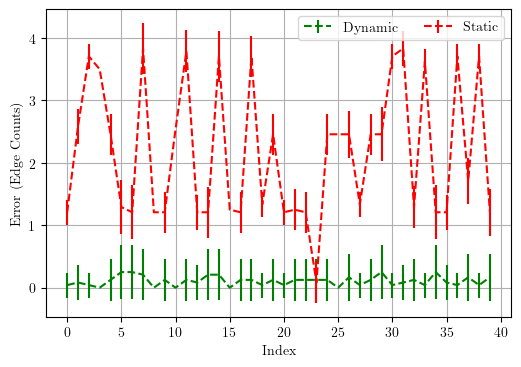

In [ ]:
plt.figure(figsize=(6, 4))
plt.errorbar(df.index, df["Error Avg"], yerr=df["Error Std"], fmt="--", label="Dynamic", color="green")
plt.errorbar(df2.index, df2["Error Avg"], yerr=df["Error Std"], fmt="--", label="Static", color="red")
plt.xlabel("Index")
plt.ylabel("Error (CFG Edge Weights)")
# plt.title("Error Rate with Error Bars")
plt.grid(True)
plt.legend(ncol=2)
plt.savefig("error_rate.pdf")
plt.show()



/tmp/ipykernel_2198715/2128201381.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Type", y="Error Avg", data=combined_data, palette={"Dynamic": "green", "Static": "red"})


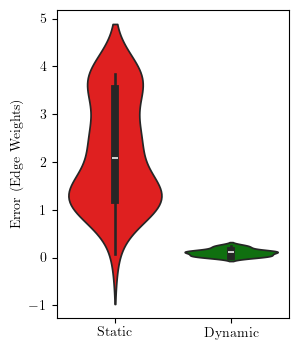

In [ ]:
combined_data = pd.DataFrame({
    "Error Avg": list(df2["Error Avg"]) + list(df["Error Avg"]),
    "Type": ["Static"] * len(df2) +["Dynamic"] * len(df) 
})

# Plot
plt.figure(figsize=(3, 4))
sns.violinplot(x="Type", y="Error Avg", data=combined_data, palette={"Dynamic": "green", "Static": "red"})
plt.xlabel('')
plt.ylabel("Error (CFG Edge Weights)")
# plt.title("Distribution of Error")
# plt.legend()
plt.savefig("error_rate_violin.pdf")
plt.show()



In [24]:
dynamic_true_percentage = df["Hot Path Predicted"].mean() * 100
print(f"Prediction True Percentage with dynamic Info: {dynamic_true_percentage:.2f}%")
static_true_percentage = df2["Hot Path Predicted"].mean() * 100
print(f"Prediction True Percentage without dynamic Info: {static_true_percentage:.2f}%")


Prediction True Percentage with dynamic Info: 90.00%
Prediction True Percentage without dynamic Info: 95.00%
